count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_len, dtype: float64


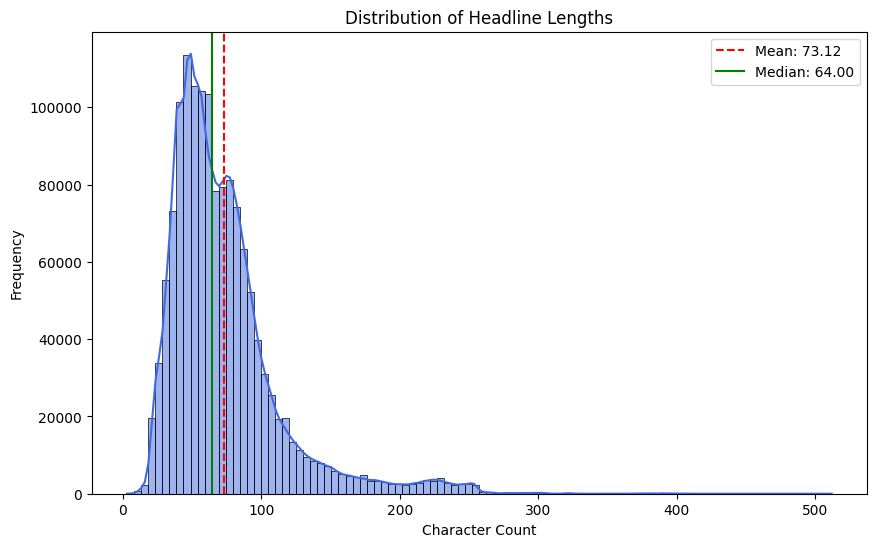

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv("C:/Users/nemsa/News-Sentiment-Analysis/data/raw/raw_analyst_ratings.csv")

# Task: Obtain basic statistics for textual lengths
df['headline_len'] = df['headline'].str.len()
print(df['headline_len'].describe())

# Plot the frequency distribution graph
plt.figure(figsize=(10, 6))
sns.histplot(df['headline_len'], bins=100, kde=True, color='royalblue')
plt.axvline(df['headline_len'].mean(), color='red', linestyle='--', label=f'Mean: {df["headline_len"].mean():.2f}')
plt.axvline(df['headline_len'].median(), color='green', linestyle='-', label=f'Median: {df["headline_len"].median():.2f}')

plt.title('Distribution of Headline Lengths')
plt.xlabel('Character Count')
plt.ylabel('Frequency')
plt.legend()
plt.show()

What does this mean?

1. The "Typical" Headline

    * Mean (~73 chars): the average headline is about the length of a short sentence or a long tweet.

    * Median (50% mark at 64 chars): Since the mean (73) is higher than the median (64), the data is positively skewed. This means the dataset has a "long tail" of very long headlines pulling the average up.

2. The Spread (Variation)

    * Standard Deviation (~40): This is quite high relative to the mean. It tells us that headlines aren't all "roughly the same"—they vary quite a bit from the average.

    * The Range: The dataset has everything from tiny 3-character snippets (just stock tickers like "AAPL") to a massive 512-character headline (which is practically a full paragraph).

3. Outlier Check

    The Max (512): A 512-character headline is extremely unusual for financial news. These very long headlines might contain extra "noise" or multiple sentences and might affect future analysis.

In [16]:
# Task: Count articles per publisher
publisher_counts = df['publisher'].value_counts()
# Print the top 10 publishers
print(publisher_counts.head(10))

publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64


In [18]:
# Task: Analyze publication dates to identify trends over time

print(df['date'].head())  #check date format

# Converting into proper Python datetime object
# Create a NEW column so not to lose the old one
df['date_dt'] = pd.to_datetime(df['date'], errors='coerce')

# Now check where it failed by comparing them
print(df[df['date_dt'].isna()][['date']].head(10))

# Check for any failures
print(f"Number of unparseable dates: {df['date'].isna().sum()}")

# 1. Strip any hidden whitespace from the strings first
#df['date'] = df['date'].astype(str).str.strip()

# 2. Use a specific format string or let pandas infer more flexibly
# 'iso8601' is great for the format you showed
#df['date'] = pd.to_datetime(df['date'], format='ISO8601', errors='coerce')

# 3. Check the count again
#print(f"Remaining unparseable dates: {df['date'].isna().sum()}")

# Look at the first 10 rows that pandas couldn't read
#print(df[df['date'].isna()]['date_original_column_name'].head(10)) 
# (Replace 'date_original_column_name' with whatever the column was called before conversion)


0    2020-06-05 10:30:54-04:00
1    2020-06-03 10:45:20-04:00
2    2020-05-26 04:30:07-04:00
3    2020-05-22 12:45:06-04:00
4    2020-05-22 11:38:59-04:00
Name: date, dtype: str
                   date
10  2020-05-22 00:00:00
11  2020-05-22 00:00:00
12  2020-05-21 00:00:00
13  2020-05-21 00:00:00
14  2020-05-21 00:00:00
15  2020-05-21 00:00:00
16  2020-05-18 00:00:00
17  2020-05-16 00:00:00
18  2020-05-15 00:00:00
19  2020-05-08 00:00:00
Number of unparseable dates: 0
